## Frame Extraction 

In [1]:
import cv2
import os

video_path = r"C:\Users\Nimesh\Downloads\ICT2403_New\Videos\IMG_6025.MOV"
output_folder = r"C:\Users\Nimesh\Downloads\ICT2403_New\Frames"

os.makedirs(output_folder, exist_ok=True)

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error opening video file")
    exit()

frame_index = 0
saved_count = 0

while True:
    ret, frame = cap.read()
    
    if not ret:
        break

    #frame = cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE)
    # Save every 10th frame
    if frame_index % 10 == 0:
        filename = os.path.join(output_folder, f"frame_{saved_count:05d}.jpg")
        cv2.imwrite(filename, frame)
        saved_count += 1
    
    frame_index += 1

cap.release()

print(f"Done! Saved {saved_count} frames.")

Done! Saved 92 frames.


## Frames Enhancement

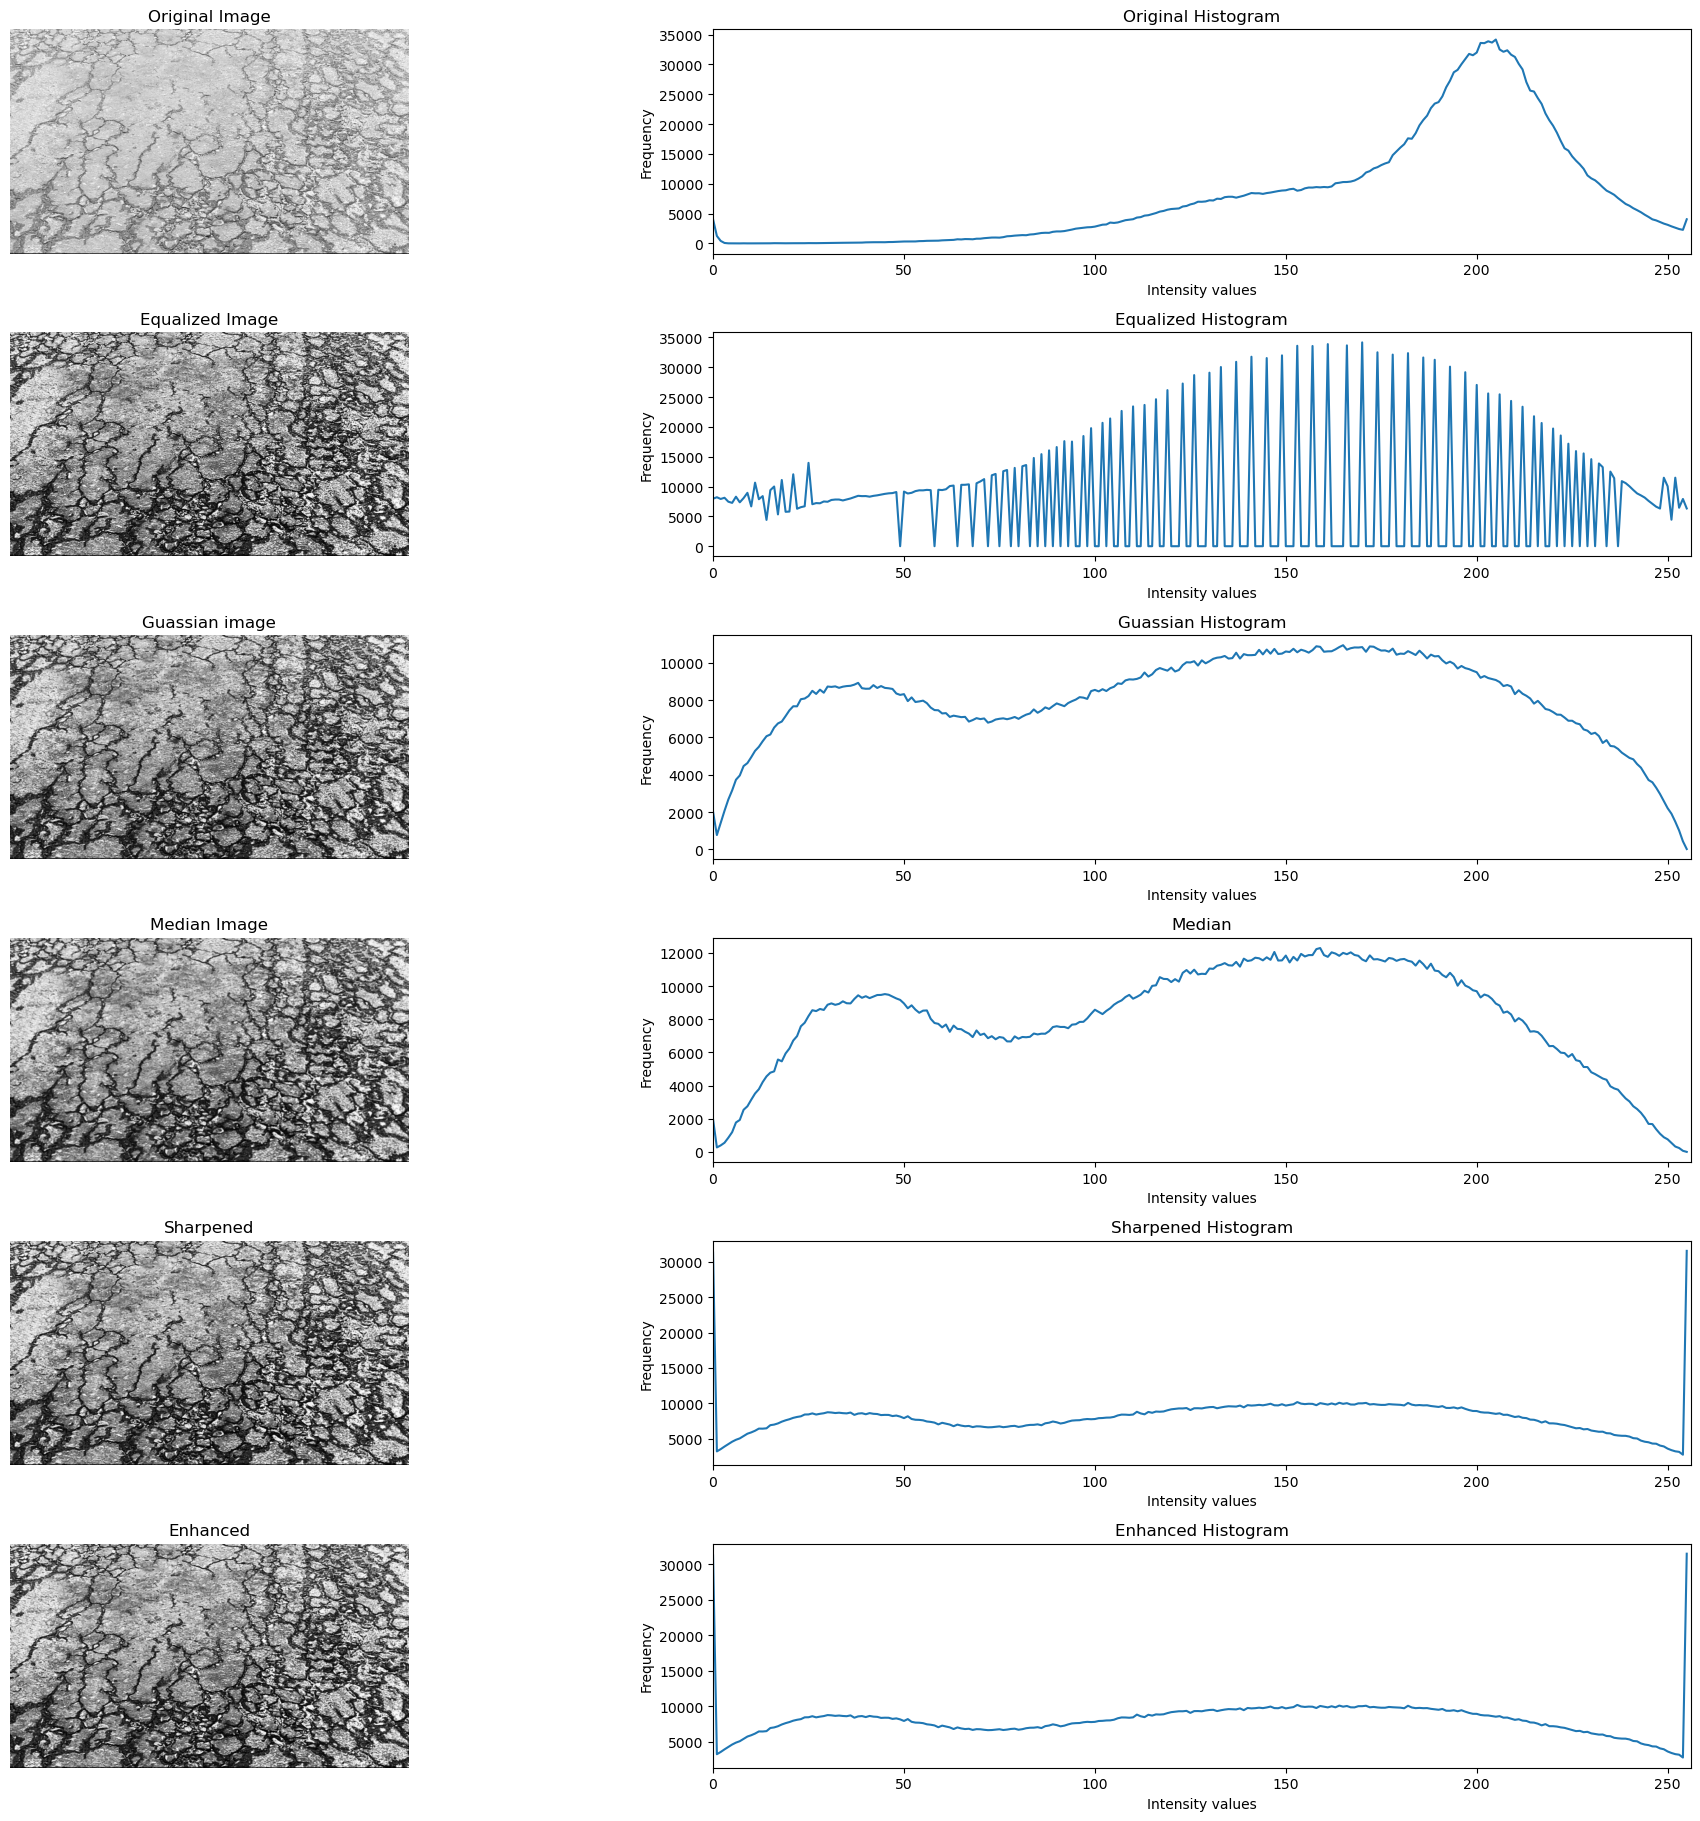

Output Display Completed.


In [35]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

def histogram(image,title):
    histogram = cv2.calcHist([image],[0],None,[256],[0,256])

    plt.title(title)
    plt.xlabel("Intensity values")
    plt.ylabel("Frequency")
    plt.plot(histogram)
    plt.xlim([0,256])



# SAVE FILES INTO THE FOLDER PATH

# Input path
input_folder = r"C:\Users\Nimesh\Downloads\ICT2403_New\Frames"

# Eqaulized output folder path
equalized_output = r"C:\Users\Nimesh\Downloads\ICT2403_New\Equalized_Frames"

# equalized_guassian folder path
equalized_guassian = r"C:\Users\Nimesh\Downloads\ICT2403_New\Equalized_Guassian_Frames"

# Equalized_Guassian_Median folder path
equalized_guassian_median = r"C:\Users\Nimesh\Downloads\ICT2403_New\Equalized_Guassianed_Median_Frames"

# Equalized_Guassianed_Median_Sharpened folder path
equalized_guassian_median_sharpend = r"C:\Users\Nimesh\Downloads\ICT2403_New\Equalized_Guassianed_Median_Sharpened_Frames"

# Final folder path
output_folder = r"C:\Users\Nimesh\Downloads\ICT2403_New\Final_Enhanced_Frames"



# Create output folder if it doesn't exist
os.makedirs(equalized_output, exist_ok=True)
os.makedirs(equalized_guassian, exist_ok=True)
os.makedirs(equalized_guassian_median, exist_ok=True)
os.makedirs(equalized_guassian_median_sharpend, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)


#image_extensions = ('.png', '.jpg', '.jpeg', '.tif', '.bmp')


# Loop through all images
for filename in os.listdir(input_folder)[:1]:

    #if filename.lower().endswith(image_extensions):

        input_path = os.path.join(input_folder, filename)
        img = cv2.imread(input_path, 0)

        if img is None:
            continue


    # Equalization Apply
        equalized = cv2.equalizeHist(img)

    # Noice Remoeval
        # Guassian Apply
        guassian = cv2.GaussianBlur(equalized,(5,5),1.0)
        # Median Apply
        median = cv2.medianBlur(guassian,(5))

    # Calculate Sharpness
        laplacian = cv2.Laplacian(median, cv2.CV_64F)
        sharpness = laplacian.var()

    # Apply sharpening
        sharpened = median - laplacian
        sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
        enhanced = sharpened


    
        plt.figure(figsize =(20,30))

    
    # Display Original Image 
        plt.subplot(10, 2, 1)
        plt.imshow(img, cmap='gray')
        plt.title("Original Image")
        plt.axis('off')
    # Display Original Image Histogram
        plt.subplot(10,2,2)
        histogram(img,"Original Histogram")

    
    # Display Equalized Image
        plt.subplot(10, 2, 3)
        plt.imshow(equalized, cmap='gray')
        plt.title("Equalized Image")
        plt.axis('off')
    # Display Equalized Image Histogram
        plt.subplot(10, 2, 4)
        histogram(equalized, "Equalized Histogram")

    
    # Display Equalized_Guassian Image
        plt.subplot(10,2,5)
        plt.imshow(guassian, cmap='gray')
        plt.title("Guassian image")
        plt.axis('off')
    # Display Equalized_Guassian Image Histogram
        plt.subplot(10,2,6)
        histogram(guassian,"Guassian Histogram")

    
    # Display Equalized_Guassianed_Median Image
        plt.subplot(10,2,7)
        plt.imshow(median, cmap='gray')
        plt.title("Median Image")
        plt.axis('off')
    # Display Equalized_Guassianed_Median Image Histogram
        plt.subplot(10,2,8)
        histogram(median,"Median")

    
    # Display Equalized_Guassianed_Median_Sharpened Image
        plt.subplot(10,2,9)
        plt.imshow(sharpened, cmap='gray')
        plt.title("Sharpened")
        plt.axis("off")
    # Display Equalized_Guassianed_Median_Sharpened Image Histogram
        plt.subplot(10,2,10)
        histogram(sharpened,"Sharpened Histogram")

    # Display Equalized_Guassianed_Median_Sharpened Image
        plt.subplot(10,2,11)
        plt.imshow(enhanced, cmap='gray')
        plt.title("Enhanced")
        plt.axis("off")
    # Display Equalized_Guassianed_Median_Sharpened Image Histogram
        plt.subplot(10,2,12)
        histogram(enhanced,"Enhanced Histogram")

    
        plt.tight_layout()
        plt.show()


        # SAVE FILES INTO THE FOLDER PATH
        
        # Eqaulized output folder path
        cv2.imwrite(os.path.join(equalized_output, f"{os.path.splitext(filename)[0]}_equalized.png"), equalized)

        # equalized_guassian folder path
        cv2.imwrite(os.path.join(equalized_guassian, f"{os.path.splitext(filename)[0]}_guassian.png"), guassian)

        # Equalized_Guassian_Median folder path
        cv2.imwrite(os.path.join(equalized_guassian_median, f"{os.path.splitext(filename)[0]}_median.png"), median)

        # Equalized_Guassianed_Median_Sharpened folder path
        cv2.imwrite(os.path.join(equalized_guassian_median_sharpend, f"{os.path.splitext(filename)[0]}_sharpened.png"), sharpened)

        # Final Enhanced folder path
        cv2.imwrite(os.path.join(output_folder, f"{os.path.splitext(filename)[0]}_enhanced.png"), enhanced)
        
        
print("Output Display Completed.")